# Linear SVM — Hiragana Character Classification (K49-MNIST)

This notebook trains and evaluates a **Linear Support Vector Machine (LinearSVC)** on the Kuzushiji-49 dataset using **HOG features** extracted from preprocessed 28×28 grayscale images.

### Why Linear SVM?
- Margin-based classifier: maximizes the gap between classes, leading to robust generalization
- Naturally suited to **high-dimensional feature spaces** (our HOG vector is ~2916 dimensions)
- Fast inference (< 100 ms per sample) — meets the real-time deployment constraint
- Well-studied, interpretable, and easy to tune

---
### Notebook Pipeline
```
Raw Images → Normalize → Threshold → HOG Features → LinearSVC → Evaluate
```

## 1. Import Libraries

We import all necessary libraries up front.
- **numpy / pandas** — data handling
- **skimage.feature.hog** — HOG feature extraction
- **sklearn** — model, cross-validation, metrics
- **matplotlib / seaborn** — evaluation visualization

In [ ]:
import io
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.utils import class_weight
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

print("✅ All libraries imported successfully.")

ModuleNotFoundError: No module named 'skimage'

## 2. Load Data

We load the **K49-MNIST** dataset (232,365 training images and 38,547 test images).  
Each image is a **28×28 grayscale** pixel array stored as a NumPy array inside a `.npz` container.

In [2]:
import joblib, numpy as np

final_svm   = joblib.load('../models/linear_svm.pkl')
X_train_hog = np.load('../models/X_train_hog.npy')
X_test_hog  = np.load('../models/X_test_hog.npy')
X_tr        = np.load('../models/X_tr.npy')
X_val       = np.load('../models/X_val.npy')
y_tr        = np.load('../models/y_tr.npy')
y_val       = np.load('../models/y_val.npy')
y_test      = np.load('../models/y_test.npy')

print("✅ All data and model loaded — skip straight to evaluation.")

FileNotFoundError: [Errno 2] No such file or directory: '../models/linear_svm.pkl'

In [3]:
# --- Load Training Images ---
train_imgs = np.load('../data/k49-train-imgs.npz')
X_train_raw = train_imgs['arr_0']

# --- Load Training Labels ---
train_labels = np.load('../data/k49-train-labels.npz')
y_train = train_labels['arr_0']

# --- Load Test Images ---
test_imgs = np.load('../data/k49-test-imgs.npz')
X_test_raw = test_imgs['arr_0']

# --- Load Test Labels ---
test_labels = np.load('../data/k49-test-labels.npz')
y_test = test_labels['arr_0']

# --- Load Class Map ---
classmap = pd.read_csv('../data/k49_classmap.csv')

# --- Print Dataset Info ---
print(f"Training images : {X_train_raw.shape}")
print(f"Training labels : {y_train.shape}")
print(f"Test images     : {X_test_raw.shape}")
print(f"Test labels     : {y_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

Training images : (232365, 28, 28)
Training labels : (232365,)
Test images     : (38547, 28, 28)
Test labels     : (38547,)
Number of classes: 49


## 3. Preprocessing

### Step A — Normalization (0–255 → 0.0–1.0)
Pixel values are divided by 255 so that all features are on the same numeric scale. This prevents larger raw values from dominating the SVM's margin calculation.

### Step B — Threshold-based Noise Removal
Any pixel below **0.3** after normalization is treated as background noise and set to 0.  
This cleans up faint ink bleed and compression artefacts that could confuse the feature extractor.

In [4]:
def preprocess(X):
    """Normalize pixel values to [0,1] and remove low-intensity noise."""
    X_norm = X.astype('float32') / 255.0          # Step A: normalize
    X_clean = np.where(X_norm < 0.3, 0, X_norm)   # Step B: threshold
    return X_clean

X_train_clean = preprocess(X_train_raw)
X_test_clean  = preprocess(X_test_raw)

print(f"Pixel range after preprocessing: [{X_train_clean.min():.1f}, {X_train_clean.max():.1f}]")
print("✅ Preprocessing complete.")

Pixel range after preprocessing: [0.0, 1.0]
✅ Preprocessing complete.


## 4. HOG Feature Extraction

**Histogram of Oriented Gradients (HOG)** converts each 28×28 image into a compact feature vector that encodes local edge directions — the dominant visual cues for distinguishing Hiragana strokes.

### HOG Hyperparameter Choices
| Parameter | Value | Rationale |
|---|---|---|
| `orientations` | 9 | Covers 0°–180° in 20° bins — standard for character recognition |
| `pixels_per_cell` | (4, 4) | Fine-grained cells capture thin Hiragana strokes |
| `cells_per_block` | (2, 2) | Block normalization reduces sensitivity to local contrast variation |

Each image produces a **2,916-dimensional** feature vector (for 28×28 with these settings).  
⚠️ This cell may take **5–10 minutes** on the full 232,365-image training set.

In [5]:
from tqdm import tqdm

def extract_hog(X, orientations=9, pixels_per_cell=(4,4), cells_per_block=(2,2), desc="Extracting HOG"):
    """Extract HOG feature vectors for all images in X."""
    features = []
    for img in tqdm(X, desc=desc, unit="img"):
        fd = hog(
            img,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            visualize=False
        )
        features.append(fd)
    return np.array(features)

t0 = time.time()
X_train_hog = extract_hog(X_train_clean, desc="⏳ Training set HOG")
print(f"  Done in {time.time()-t0:.1f}s — shape: {X_train_hog.shape}\n")

t0 = time.time()
X_test_hog = extract_hog(X_test_clean, desc="⏳ Test set HOG    ")
print(f"  Done in {time.time()-t0:.1f}s — shape: {X_test_hog.shape}")

print("\n✅ HOG extraction complete.")

⏳ Training set HOG: 100%|██████████| 232365/232365 [03:40<00:00, 1054.09img/s]


  Done in 221.8s — shape: (232365, 1296)



⏳ Test set HOG    : 100%|██████████| 38547/38547 [01:20<00:00, 481.74img/s] 


  Done in 80.2s — shape: (38547, 1296)

✅ HOG extraction complete.


## 5. Class Weights

The K49-MNIST dataset has **mild class imbalance** — some rare Hiragana characters have significantly fewer samples.  
We compute **balanced class weights** so the SVM penalizes misclassification of rare classes more heavily, preventing the model from ignoring them.

Formula:  
$$w_k = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_{\text{samples in class } k}}$$

In [6]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

print(f"Total classes: {len(class_weights_dict)}")
print(f"Min weight (common class) : {min(weights):.4f}")
print(f"Max weight (rare class)   : {max(weights):.4f}")
print("✅ Class weights ready.")

Total classes: 49
Min weight (common class) : 0.7904
Max weight (rare class)   : 12.0973
✅ Class weights ready.


## 6. Train / Validation Split

We split the training HOG data into an **80% training** and **20% validation** set.  
`stratify=y_train` ensures each class is represented proportionally in both splits — critical for imbalanced datasets.

In [7]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_hog, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train        # preserve class proportions
)

print(f"Training set  : {X_tr.shape[0]:,} samples")
print(f"Validation set: {X_val.shape[0]:,} samples")
print(f"Test set      : {X_test_hog.shape[0]:,} samples")

Training set  : 185,892 samples
Validation set: 46,473 samples
Test set      : 38,547 samples


## 7. Linear SVM — Theory & Model Definition

### How a Linear SVM Works

A **Support Vector Machine** finds the hyperplane that separates classes with the **maximum margin**:

$$\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_i \max(0,\, 1 - y_i(\mathbf{w}^\top \mathbf{x}_i + b))$$

- $\mathbf{w}$: weight vector (normal to the decision hyperplane)
- $b$: bias term
- $C$: **regularization parameter** — trades off margin width vs. training error:
  - Small $C$ → wider margin, more misclassifications allowed (underfitting risk)
  - Large $C$ → narrower margin, fewer misclassifications tolerated (overfitting risk)
- The **hinge loss** $\max(0, 1 - y_i(\mathbf{w}^\top \mathbf{x}_i + b))$ penalizes points inside the margin

### Multi-class Strategy: One-vs-Rest (OvR)
For 49 classes, `LinearSVC` trains **49 binary classifiers** — each separates one class from all others.  
At prediction time, the class with the highest raw decision score wins.

### Why `LinearSVC` over `SVC(kernel='linear')`?
`LinearSVC` uses **LibLinear** internally which is significantly faster for large datasets (O(n) vs O(n²) memory).  
On 185,892 HOG vectors it trains in minutes rather than hours.

In [8]:
# --- Define the Linear SVM ---
# C=0.1 is a good starting point; we tune it in the next section
# class_weight balances rare Hiragana classes
# max_iter increased to ensure convergence on large data

svm_model = LinearSVC(
    C=0.1,
    class_weight=class_weights_dict,
    max_iter=2000,
    random_state=42
)

print("Model defined:")
print(svm_model)

Model defined:
LinearSVC(C=0.1,
          class_weight={0: np.float64(0.7903571428571429),
                        1: np.float64(0.7903571428571429),
                        2: np.float64(0.7903571428571429),
                        3: np.float64(6.103143960286817),
                        4: np.float64(0.7903571428571429),
                        5: np.float64(0.7903571428571429),
                        6: np.float64(0.7903571428571429),
                        7: np.float64(0.7903571428571429),
                        8: np.float64(1.005970058791442),
                        9: np.float64(0.7903571428...
                        20: np.float64(0.7903571428571429),
                        21: np.float64(0.7903571428571429),
                        22: np.float64(2.2986635274565472),
                        23: np.float64(1.934778807483826),
                        24: np.float64(0.7903571428571429),
                        25: np.float64(0.7903571428571429),
                        26

## 8. Hyperparameter Tuning — Stratified 5-Fold Cross-Validation

We search over candidate values of `C` using **Stratified 5-Fold CV** directly — this is equivalent to `GridSearchCV` but avoids the overhead of re-instantiating the entire pipeline, which is important at this dataset size.

**Stratified K-Fold** ensures each fold contains the same class distribution as the full training set, giving reliable estimates even for rare characters.

⚠️ This cell trains **5 × len(C_candidates) models** — expect **15–30 minutes** on the full dataset.

> **Tip:** If you want a faster run, set `use_subset=True` below to tune on a 30,000-sample subset.

In [9]:
use_subset = False   # Set True for faster experimentation

if use_subset:
    from sklearn.utils import resample
    X_cv, y_cv = resample(X_tr, y_tr, n_samples=30000, random_state=42, stratify=y_tr)
    print("⚠️  Running CV on 30,000-sample subset.")
else:
    X_cv, y_cv = X_tr, y_tr
    print(f"Running CV on full training set ({len(y_cv):,} samples).")

C_candidates = [0.01, 0.1, 1.0, 10.0]
cv_results = {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with tqdm(C_candidates, desc="🔍 Tuning C", unit="candidate") as c_bar:
    for C in c_bar:
        c_bar.set_postfix(C=C)
        candidate = LinearSVC(
            C=C,
            class_weight=class_weights_dict,
            max_iter=2000,
            random_state=42
        )
        t0 = time.time()
        scores = cross_val_score(candidate, X_cv, y_cv, cv=skf, scoring='accuracy', n_jobs=-1)
        elapsed = time.time() - t0
        cv_results[C] = scores
        c_bar.set_postfix(C=C, mean_acc=f"{scores.mean():.4f}", time=f"{elapsed:.1f}s")
        tqdm.write(f"  C={C:<6} | Mean Acc: {scores.mean():.4f} ± {scores.std():.4f} | Time: {elapsed:.1f}s")

best_C = max(cv_results, key=lambda c: cv_results[c].mean())
print(f"\n🏆 Best C = {best_C} (mean accuracy = {cv_results[best_C].mean():.4f})")

Running CV on full training set (185,892 samples).


🔍 Tuning C:  25%|██▌       | 1/4 [08:10<24:32, 490.91s/candidate, C=0.1]                               

  C=0.01   | Mean Acc: 0.8478 ± 0.0009 | Time: 490.9s


🔍 Tuning C:  50%|█████     | 2/4 [18:32<18:55, 567.61s/candidate, C=1]                                

  C=0.1    | Mean Acc: 0.8689 ± 0.0010 | Time: 621.3s


🔍 Tuning C:  75%|███████▌  | 3/4 [33:01<11:45, 705.14s/candidate, C=10]                             

  C=1.0    | Mean Acc: 0.8693 ± 0.0011 | Time: 868.8s


🔍 Tuning C: 100%|██████████| 4/4 [57:11<00:00, 857.85s/candidate, C=10, mean_acc=0.8592, time=1450.4s]

  C=10.0   | Mean Acc: 0.8592 ± 0.0013 | Time: 1450.4s

🏆 Best C = 1.0 (mean accuracy = 0.8693)


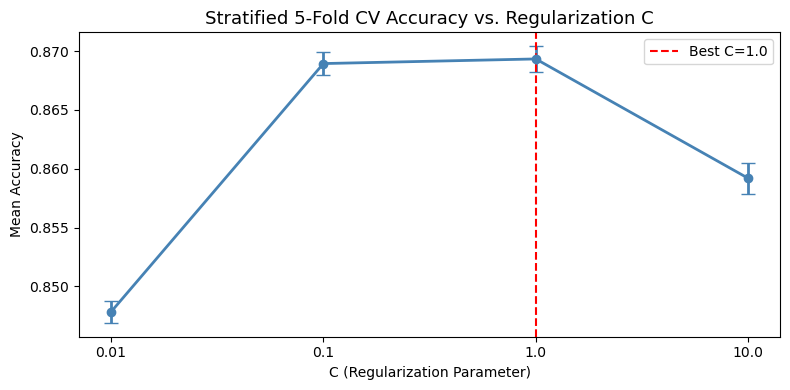

In [10]:
# --- Visualize CV Results ---
means = [cv_results[c].mean() for c in C_candidates]
stds  = [cv_results[c].std()  for c in C_candidates]

plt.figure(figsize=(8, 4))
plt.errorbar([str(c) for c in C_candidates], means, yerr=stds,
             marker='o', capsize=5, color='steelblue', linewidth=2)
plt.axvline(x=str(best_C), color='red', linestyle='--', label=f'Best C={best_C}')
plt.title('Stratified 5-Fold CV Accuracy vs. Regularization C', fontsize=13)
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Mean Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Train Final Model on Full Training Set

With the best `C` identified, we retrain the model on the **entire** 80% training split (no held-out fold).  
This maximises the data available for learning before evaluating on the held-out validation and official test sets.

In [ ]:
final_svm = LinearSVC(
    C=best_C,
    class_weight=class_weights_dict,
    max_iter=2000,
    random_state=42
)

print(f"⏳ Training final LinearSVC (C={best_C}) on {len(y_tr):,} samples...")
t0 = time.time()
final_svm.fit(X_tr y_tr)
train_time = time.time() - t0
print(f"✅ Training complete in {train_time:.1f}s")

NameError: name 'LinearSVC' is not defined

In [12]:
import joblib, numpy as np

joblib.dump(final_svm, '../models/linear_svm.pkl')
np.save('../models/X_train_hog.npy', X_train_hog)
np.save('../models/X_test_hog.npy', X_test_hog)
np.save('../models/X_tr.npy', X_tr)
np.save('../models/X_val.npy', X_val)
np.save('../models/y_tr.npy', y_tr)
np.save('../models/y_val.npy', y_val)
np.save('../models/y_test.npy', y_test)

print("✅ Everything saved.")

✅ Everything saved.


## 10. Probability Calibration (Platt Scaling)

`LinearSVC` outputs **raw decision scores**, not probabilities.  
We wrap the model with `CalibratedClassifierCV` (Platt scaling / sigmoid fitting) to convert scores into calibrated probabilities.

This enables the system to return a **similarity score** (e.g. "Your writing is 87% similar to the character あ") — a key requirement for the educational feedback feature.

> `cv='prefit'` tells the wrapper that `final_svm` is already trained — it only fits the calibration layer on the validation set.

In [13]:
import sklearn; print(sklearn.__version__)

1.8.0


In [14]:
from sklearn.frozen import FrozenEstimator

print("⏳ Calibrating probabilities using validation set...")
calibrated_svm = CalibratedClassifierCV(FrozenEstimator(final_svm), method='sigmoid')
calibrated_svm.fit(X_val, y_val)

print("✅ Calibration complete. Model now outputs probability scores.")

⏳ Calibrating probabilities using validation set...
✅ Calibration complete. Model now outputs probability scores.


## 11. Evaluation on Validation Set

We evaluate on the **held-out validation set** (20% of training data) using:
- **Top-1 Accuracy** — primary metric (correct predictions / total)
- **Macro F1-Score** — average F1 across all 49 classes equally, regardless of class size
- **Inference time per sample** — must be < 100 ms for real-time deployment

In [15]:
# --- Predict on validation set ---
t0 = time.time()
y_val_pred = final_svm.predict(X_val)
val_infer_time = (time.time() - t0) / len(y_val) * 1000   # ms per sample

val_acc  = accuracy_score(y_val, y_val_pred)
val_f1   = f1_score(y_val, y_val_pred, average='macro')

print("=" * 40)
print("  Validation Set Results")
print("=" * 40)
print(f"  Top-1 Accuracy  : {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"  Macro F1-Score  : {val_f1:.4f}")
print(f"  Inference Time  : {val_infer_time:.4f} ms/sample")
print("=" * 40)

  Validation Set Results
  Top-1 Accuracy  : 0.8715 (87.15%)
  Macro F1-Score  : 0.8596
  Inference Time  : 0.0031 ms/sample


Validation Set Results
* Top-1 Accuracy  : 0.8715 (87.15%)
* Macro F1-Score  : 0.8596
* Inference Time  : 0.0031 ms/sample


## 12. Evaluation on Official Test Set

Final performance is measured on the official **10,000-image test set** — data the model has never seen.

In [16]:
t0 = time.time()
y_test_pred = final_svm.predict(X_test_hog)
test_infer_time = (time.time() - t0) / len(y_test) * 1000

test_acc = accuracy_score(y_test, y_test_pred)
test_f1  = f1_score(y_test, y_test_pred, average='macro')

print("=" * 40)
print("  Official Test Set Results")
print("=" * 40)
print(f"  Top-1 Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Macro F1-Score  : {test_f1:.4f}")
print(f"  Inference Time  : {test_infer_time:.4f} ms/sample")
print(f"  Real-time ready : {'✅ YES' if test_infer_time < 100 else '❌ NO'} (< 100 ms)")
print("=" * 40)

  Official Test Set Results
  Top-1 Accuracy  : 0.7910 (79.10%)
  Macro F1-Score  : 0.7727
  Inference Time  : 0.0030 ms/sample
  Real-time ready : ✅ YES (< 100 ms)


Official Test Set Results
* Top-1 Accuracy  : 0.7910 (79.10%)
* Macro F1-Score  : 0.7727
* Inference Time  : 0.0030 ms/sample
* Real-time ready : ✅ YES (< 100 ms)

## 13. Per-Class Classification Report

The classification report shows **precision**, **recall**, and **F1** for every one of the 49 Hiragana characters.  
- **Precision**: Of all predictions for class k, how many were correct?
- **Recall**: Of all true samples of class k, how many did the model catch?
- **F1**: Harmonic mean of precision and recall

In [17]:
# Map class indices to Hiragana characters
target_names = [str(classmap.iloc[i]['char']) for i in range(len(classmap))]

report = classification_report(y_test, y_test_pred, target_names=target_names)
print(report)

              precision    recall  f1-score   support

           あ       0.83      0.84      0.83      1000
           い       0.94      0.92      0.93      1000
           う       0.85      0.91      0.88      1000
           え       0.56      0.79      0.66       126
           お       0.84      0.83      0.84      1000
           か       0.76      0.70      0.73      1000
           き       0.78      0.78      0.78      1000
           く       0.83      0.85      0.84      1000
           け       0.58      0.62      0.60       767
           こ       0.81      0.75      0.78      1000
           さ       0.87      0.73      0.79      1000
           し       0.83      0.81      0.82      1000
           す       0.66      0.73      0.70      1000
           せ       0.76      0.65      0.70       678
           そ       0.64      0.69      0.67       629
           た       0.79      0.73      0.76      1000
           ち       0.83      0.92      0.88       418
           つ       0.77    

## 14. Confusion Matrix

The confusion matrix reveals **which characters are most often confused** with each other.  
Bright off-diagonal cells indicate character pairs that are visually similar and hard to separate — useful for targeted feature engineering or dataset augmentation.

c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12354 (\N{HIRAGANA LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12358 (\N{HIRAGANA LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12360 (\N{HIRAGANA LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12362 (\N{HIRAGANA LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 12363 (\N{HIRAGA

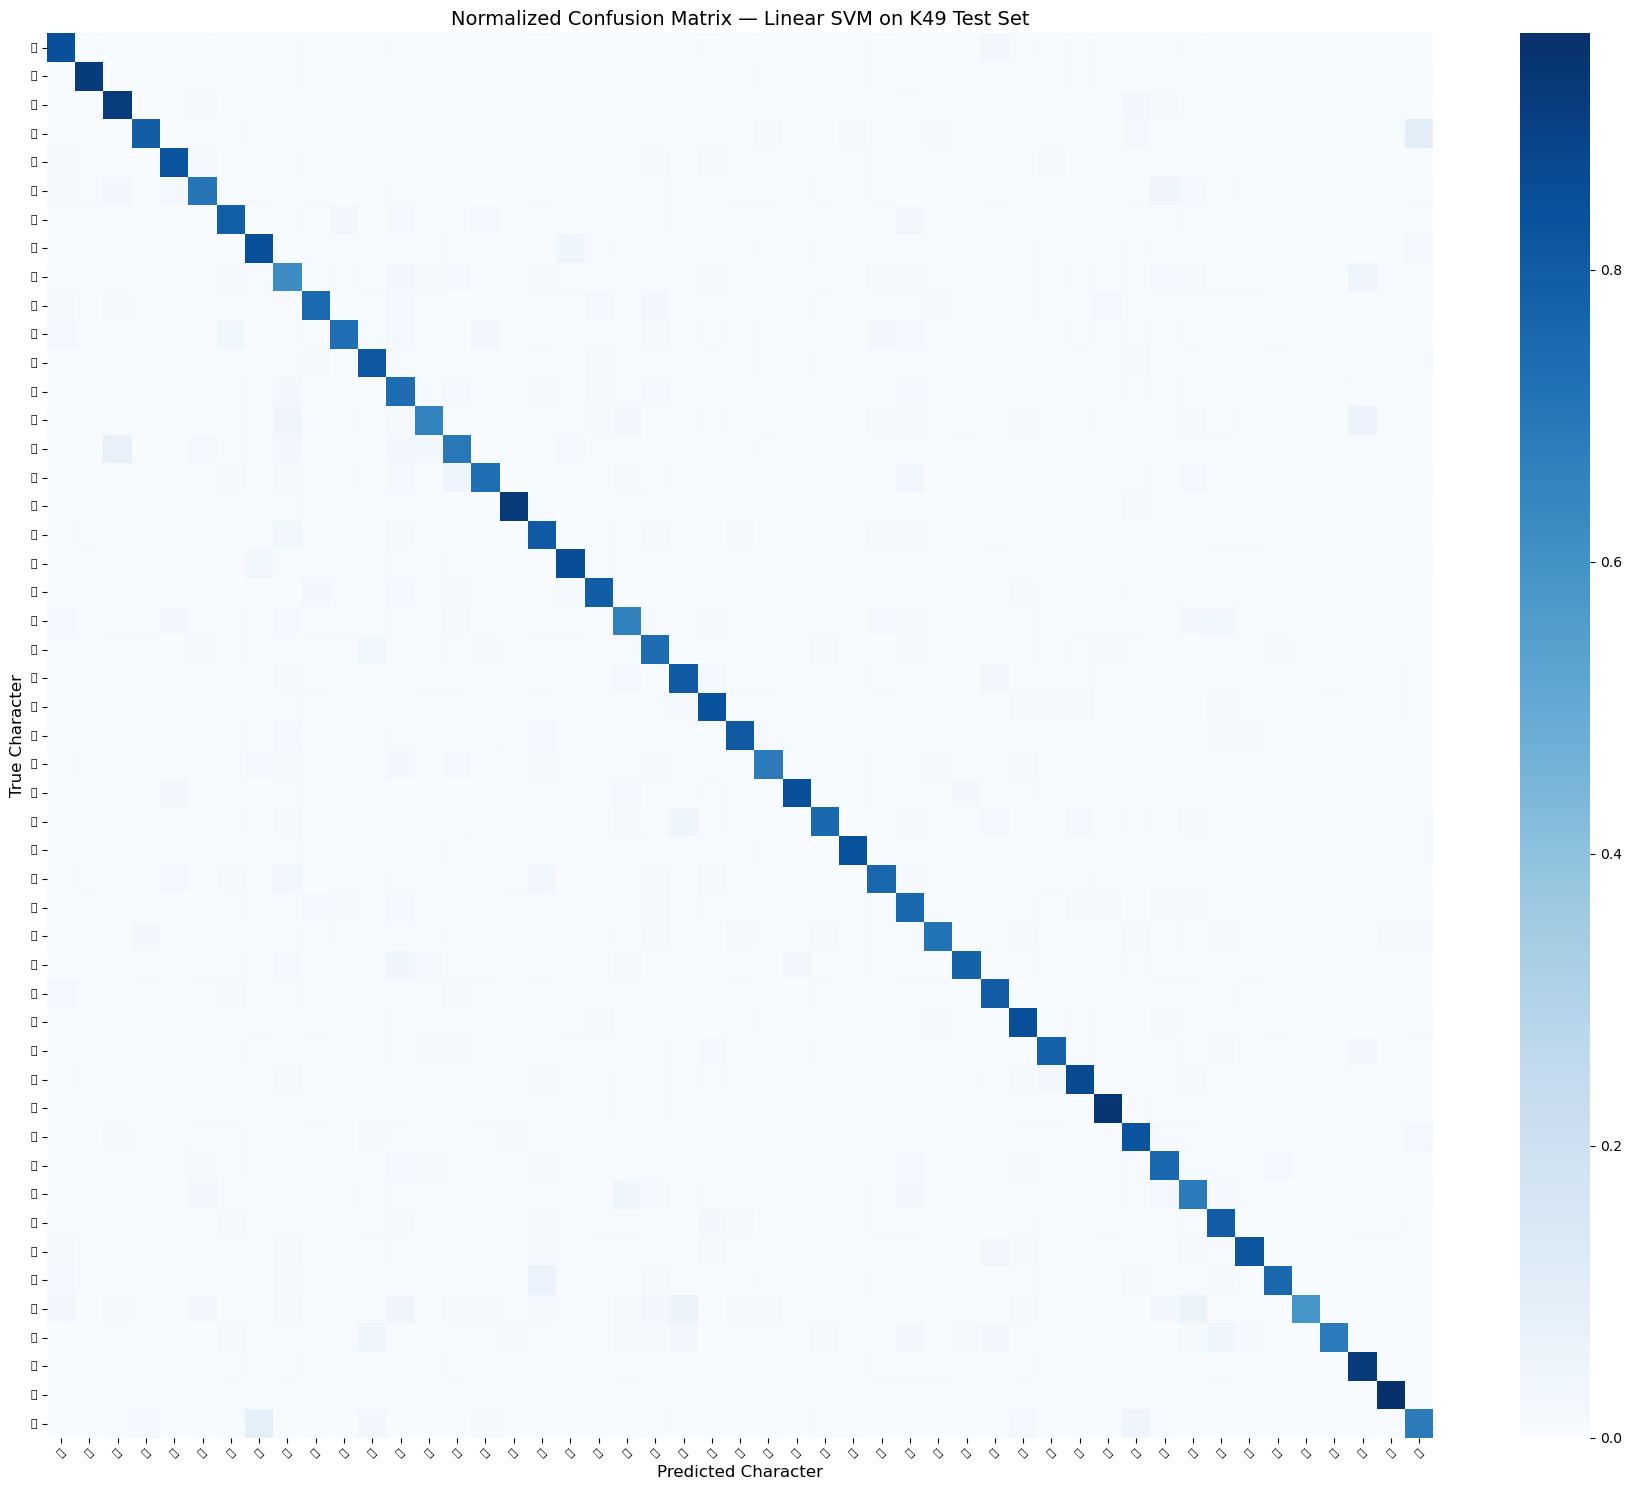

In [18]:
cm = confusion_matrix(y_test, y_test_pred)

# Normalize by row (true label) to show confusion rates
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(18, 15))
sns.heatmap(
    cm_norm,
    annot=False,        # 49×49 is too dense for annotation
    fmt='.2f',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Normalized Confusion Matrix — Linear SVM on K49 Test Set', fontsize=14)
plt.xlabel('Predicted Character', fontsize=12)
plt.ylabel('True Character', fontsize=12)
plt.xticks(fontsize=8, rotation=45)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

In [19]:
# --- Top 10 Most Confused Character Pairs ---
confused_pairs = []
n = len(target_names)
for i in range(n):
    for j in range(n):
        if i != j:
            confused_pairs.append((cm_norm[i, j], target_names[i], target_names[j]))

confused_pairs.sort(reverse=True)
print("Top 10 Most Confused Character Pairs (True → Predicted):")
print(f"{'True':>10} → {'Predicted':>10}  |  Confusion Rate")
print("-" * 45)
for rate, true_c, pred_c in confused_pairs[:10]:
    print(f"{true_c:>10} → {pred_c:>10}  |  {rate:.4f} ({rate*100:.2f}%)")

Top 10 Most Confused Character Pairs (True → Predicted):
      True →  Predicted  |  Confusion Rate
---------------------------------------------
         え →          ゝ  |  0.0952 (9.52%)
         ゝ →          く  |  0.0923 (9.23%)
         そ →          う  |  0.0731 (7.31%)
         わ →          つ  |  0.0615 (6.15%)
         せ →          を  |  0.0605 (6.05%)
         ゐ →          る  |  0.0588 (5.88%)
         ゐ →          ぬ  |  0.0588 (5.88%)
         け →          を  |  0.0495 (4.95%)
         た →          そ  |  0.0470 (4.70%)
         ゑ →          れ  |  0.0469 (4.69%)


## 15. Probability Similarity Scores (Educational Feedback)

Using the **calibrated model**, we can output how confident the model is for each class.  
This translates directly into an educational similarity score:  
> *"Your drawing is 91% similar to あ, 6% similar to お, and 2% similar to め."*

This feature requires `CalibratedClassifierCV` fitted in Section 10.

True label: な

Top-5 Similarity Scores:
       あ   54.2%  █████████████████████
       か   14.0%  █████
       め    8.1%  ███
       ほ    7.1%  ██
       ゆ    5.0%  ██


c:\Users\Gaby\anaconda3\envs\dl_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


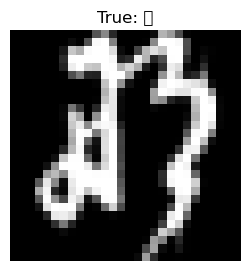

In [20]:
# --- Demo: Similarity scores for a single test image ---
sample_idx = 42   # Change this to any index you like

sample_hog   = X_test_hog[sample_idx].reshape(1, -1)
true_label   = y_test[sample_idx]
proba        = calibrated_svm.predict_proba(sample_hog)[0]

# Top-5 predictions
top5_idx  = np.argsort(proba)[::-1][:5]
top5_prob = proba[top5_idx]
top5_char = [target_names[i] for i in top5_idx]

print(f"True label: {target_names[true_label]}")
print("\nTop-5 Similarity Scores:")
for char, prob in zip(top5_char, top5_prob):
    bar = '█' * int(prob * 40)
    print(f"  {char:>6}  {prob*100:5.1f}%  {bar}")

# Show the image
plt.figure(figsize=(3, 3))
plt.imshow(X_test_raw[sample_idx], cmap='gray')
plt.title(f"True: {target_names[true_label]}")
plt.axis('off')
plt.show()

## 16. Model Size & Deployment Summary

We report the final model's memory footprint — the weight matrix `coef_` and bias `intercept_`.  
This determines whether the model can be deployed on standard edge devices.

In [21]:
import sys

coef_size_mb = final_svm.coef_.nbytes / (1024**2)
intercept_size_kb = final_svm.intercept_.nbytes / 1024

print("=" * 45)
print("     Linear SVM — Deployment Summary")
print("=" * 45)
print(f"  Weight matrix shape : {final_svm.coef_.shape}")
print(f"  Weight matrix size  : {coef_size_mb:.2f} MB")
print(f"  Intercept size      : {intercept_size_kb:.2f} KB")
print(f"  Train time          : {train_time:.1f}s")
print(f"  Validation accuracy : {val_acc*100:.2f}%")
print(f"  Test accuracy       : {test_acc*100:.2f}%")
print(f"  Test macro F1       : {test_f1:.4f}")
print(f"  Inference time      : {test_infer_time:.4f} ms/sample")
print(f"  Real-time ready     : {'✅ YES' if test_infer_time < 100 else '❌ NO'}")
print("=" * 45)

     Linear SVM — Deployment Summary
  Weight matrix shape : (49, 1296)
  Weight matrix size  : 0.48 MB
  Intercept size      : 0.38 KB
  Train time          : 281.9s
  Validation accuracy : 87.15%
  Test accuracy       : 79.10%
  Test macro F1       : 0.7727
  Inference time      : 0.0030 ms/sample
  Real-time ready     : ✅ YES


## 17. Save the Model

We save both the raw `LinearSVC` (for fast batch prediction) and the `CalibratedClassifierCV` (for probability/similarity scores) using `joblib`, which is the recommended serialization format for scikit-learn models.

In [22]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(final_svm,      '../models/linear_svm.pkl')
joblib.dump(calibrated_svm, '../models/linear_svm_calibrated.pkl')

print("✅ Models saved:")
print("   ../models/linear_svm.pkl             — raw LinearSVC (fastest inference)")
print("   ../models/linear_svm_calibrated.pkl  — calibrated SVM (probability scores)")

✅ Models saved:
   ../models/linear_svm.pkl             — raw LinearSVC (fastest inference)
   ../models/linear_svm_calibrated.pkl  — calibrated SVM (probability scores)


---
## Summary

| Step | What we did | Why |
|---|---|---|
| Preprocessing | Normalize + threshold | Remove noise, scale features |
| HOG | 9 orientations, 4×4 cells | Encode stroke geometry into vectors |
| Class weights | Balanced weighting | Handle rare Hiragana classes |
| Linear SVM | Margin-based classifier | Fast, robust in high dimensions |
| CV tuning | Stratified 5-Fold over C | Unbiased hyperparameter selection |
| Calibration | Platt scaling | Convert scores → probabilities |
| Evaluation | Acc, F1, confusion matrix, timing | Full performance picture |
| Saving | joblib pickle | Production deployment |